# 07 — District-Level EMS Inference Pipeline

Uses 2025 CAMS AQ daily means (per district) as features to predict daily EMS dispatch counts for each of Berlin's 12 districts.

**Data**: `data/processed/cams_daily_district_2025.csv` × `data/processed/daily_district_health.csv`  
**Features**: CAMS AQ variables + temporal features  
**Targets**: dispatch code counts per district per day  
**Split**: first 80% of available days → train, last 20% → test  
**Models**: GradientBoostingRegressor per district × target (non-linear, handles small samples)  
**Metrics**: RMSE, MAE, R² reported per district and aggregated

In [15]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.inspection import permutation_importance
import joblib

PROC_DIR  = Path('../data/processed')
MODEL_DIR = Path('../models')
MODEL_DIR.mkdir(parents=True, exist_ok=True)

DISTRICTS = [
    'Charlottenburg-Wilmersdorf', 'Friedrichshain-Kreuzberg', 'Lichtenberg',
    'Marzahn-Hellersdorf', 'Mitte', 'Neukölln', 'Pankow', 'Reinickendorf',
    'Spandau', 'Steglitz-Zehlendorf', 'Tempelhof-Schöneberg', 'Treptow-Köpenick',
]

TARGETS = [
    'code_06_breathing', 'code_09_cardiac_arrest', 'code_10_chest_pain',
    'code_17_falls', 'code_19_heart_problems', 'code_28_stroke_tia',
]

# Core AQ features (always available) + compositional vars
AQ_FEATURES = [
    'pm25', 'pm10', 'no2', 'o3', 'so2', 'no', 'co', 'nh3',
    'dust', 'pm10_sea_salt', 'pm_wildfire', 'ec_residential',
    'pm25_nh4', 'pm25_no3', 'pm25_so4', 'pm25_om', 'sia',
]

# TEMPORAL_FEATURES = ['day_of_week', 'is_weekend', 'month', 'doy_sin', 'doy_cos']

TEST_FRAC = 0.20

print('Setup complete')

Setup complete


## 1. Load and Merge Data

In [16]:
# ── CAMS district-level daily means ──────────────────────────────────────────
cams = pd.read_csv(PROC_DIR / 'cams_daily_district_2025.csv', parse_dates=['date'])
print(f'CAMS shape: {cams.shape}  |  dates: {cams.date.min().date()} – {cams.date.max().date()}')
print(f'Districts in CAMS: {sorted(cams.district.unique())}')

# ── Health data (filter to 2025) ─────────────────────────────────────────────
health = pd.read_csv(PROC_DIR / 'daily_district_health_smoothed.csv', parse_dates=['date'])
health = health[health.date.dt.year == 2025].reset_index(drop=True)
print(f'Health shape: {health.shape}  |  dates: {health.date.min().date()} – {health.date.max().date()}')

# Add doy_sin/cos if not present
if 'doy_sin' not in health.columns:
    doy = health['date'].dt.dayofyear
    health['doy_sin'] = np.sin(2 * np.pi * doy / 365.25)
    health['doy_cos'] = np.cos(2 * np.pi * doy / 365.25)

# ── Merge ────────────────────────────────────────────────────────────────────
df = pd.merge(health, cams, on=['date', 'district'], how='inner')
print(f'Merged shape: {df.shape}')
print(f'Available AQ features: {[f for f in AQ_FEATURES if f in df.columns]}')

# Filter to features that actually exist
AQ_FEATURES_AVAIL = [f for f in AQ_FEATURES if f in df.columns]
ALL_FEATURES = AQ_FEATURES_AVAIL 
print(f'Total features: {len(ALL_FEATURES)}')

CAMS shape: (4380, 87)  |  dates: 2025-01-01 – 2025-12-31
Districts in CAMS: ['Charlottenburg-Wilmersdorf', 'Friedrichshain-Kreuzberg', 'Lichtenberg', 'Marzahn-Hellersdorf', 'Mitte', 'Neukölln', 'Pankow', 'Reinickendorf', 'Spandau', 'Steglitz-Zehlendorf', 'Tempelhof-Schöneberg', 'Treptow-Köpenick']
Health shape: (4380, 24)  |  dates: 2025-01-01 – 2025-12-31
Merged shape: (4380, 109)
Available AQ features: ['pm25', 'pm10', 'no2', 'o3', 'so2', 'no', 'co', 'nh3', 'dust', 'pm10_sea_salt', 'pm_wildfire', 'ec_residential', 'pm25_nh4', 'pm25_no3', 'pm25_so4', 'pm25_om', 'sia']
Total features: 17


In [17]:
# Missingness check
missing = df[ALL_FEATURES + TARGETS].isnull().mean().round(3)
missing_nonzero = missing[missing > 0]
if len(missing_nonzero):
    print('Columns with missing values:')
    print(missing_nonzero.to_string())
else:
    print('No missing values in feature/target columns')

print(f'\nRows per district:\n{df.groupby("district").size().to_string()}')

No missing values in feature/target columns

Rows per district:
district
Charlottenburg-Wilmersdorf    365
Friedrichshain-Kreuzberg      365
Lichtenberg                   365
Marzahn-Hellersdorf           365
Mitte                         365
Neukölln                      365
Pankow                        365
Reinickendorf                 365
Spandau                       365
Steglitz-Zehlendorf           365
Tempelhof-Schöneberg          365
Treptow-Köpenick              365


## 2. Train / Test Split

In [18]:
# Chronological split — same cut-off date for all districts
all_dates = sorted(df['date'].unique())
n_total   = len(all_dates)
n_train   = int(n_total * (1 - TEST_FRAC))
cutoff    = all_dates[n_train]

train_df = df[df['date'] <  cutoff].copy()
test_df  = df[df['date'] >= cutoff].copy()

print(f'Total dates: {n_total}  |  train: {n_train}  |  test: {n_total - n_train}')
print(f'Train: {train_df.date.min().date()} – {train_df.date.max().date()}  ({len(train_df)} rows)')
print(f'Test:  {test_df.date.min().date()}  – {test_df.date.max().date()}   ({len(test_df)} rows)')

Total dates: 365  |  train: 292  |  test: 73
Train: 2025-01-01 – 2025-10-19  (3504 rows)
Test:  2025-10-20  – 2025-12-31   (876 rows)


## 3. Fit Per-District Models

In [19]:
def fit_district_models(district, train, test, features, targets):
    """Train GBR per target for one district; return predictions and metrics."""
    tr = train[train.district == district].sort_values('date')
    te = test[test.district  == district].sort_values('date')

    if len(tr) < 5:
        return None

    scaler   = StandardScaler()
    X_train  = scaler.fit_transform(tr[features].fillna(0))
    X_test   = scaler.transform(te[features].fillna(0))

    models  = {}
    preds   = {'date': te['date'].values}
    metrics = []

    for tgt in targets:
        y_train = tr[tgt].values
        y_test  = te[tgt].values

        gbr = GradientBoostingRegressor(
            n_estimators=200, max_depth=3, learning_rate=0.05,
            subsample=0.8, random_state=42
        )
        gbr.fit(X_train, y_train)
        y_pred = np.clip(gbr.predict(X_test), 0, None)

        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        mae  = mean_absolute_error(y_test, y_pred)
        r2   = r2_score(y_test, y_pred) if y_test.std() > 0 else np.nan

        models[tgt]       = (gbr, scaler)
        preds[f'{tgt}_pred']   = y_pred
        preds[f'{tgt}_actual'] = y_test
        metrics.append({'district': district, 'target': tgt,
                        'rmse': rmse, 'mae': mae, 'r2': r2,
                        'n_train': len(tr), 'n_test': len(te)})

    return {'models': models, 'preds': pd.DataFrame(preds), 'metrics': metrics}


all_metrics  = []
all_preds    = {}
all_models   = {}

for district in DISTRICTS:
    result = fit_district_models(district, train_df, test_df, ALL_FEATURES, TARGETS)
    if result is None:
        print(f'{district}: insufficient training data, skipped')
        continue
    all_metrics.extend(result['metrics'])
    all_preds[district]  = result['preds']
    all_models[district] = result['models']
    print(f'{district}: done ({result["metrics"][0]["n_train"]} train / {result["metrics"][0]["n_test"]} test)')

metrics_df = pd.DataFrame(all_metrics)
print(f'\nTotal models fitted: {len(metrics_df)}')

Charlottenburg-Wilmersdorf: done (292 train / 73 test)
Friedrichshain-Kreuzberg: done (292 train / 73 test)
Lichtenberg: done (292 train / 73 test)
Marzahn-Hellersdorf: done (292 train / 73 test)
Mitte: done (292 train / 73 test)
Neukölln: done (292 train / 73 test)
Pankow: done (292 train / 73 test)
Reinickendorf: done (292 train / 73 test)
Spandau: done (292 train / 73 test)
Steglitz-Zehlendorf: done (292 train / 73 test)
Tempelhof-Schöneberg: done (292 train / 73 test)
Treptow-Köpenick: done (292 train / 73 test)

Total models fitted: 72


## 4. Performance Summary

In [20]:
# Overall summary
summary = (
    metrics_df
    .groupby('target')[['rmse', 'mae', 'r2']]
    .agg(['mean', 'std'])
    .round(3)
)
print('=== Performance across all districts ===\n')
print(summary.to_string())

print('\n=== Per-district mean R² (all targets averaged) ===')
print(metrics_df.groupby('district')['r2'].mean().sort_values(ascending=False).round(3).to_string())

=== Performance across all districts ===

                         rmse           mae            r2       
                         mean    std   mean    std   mean    std
target                                                          
code_06_breathing       2.100  0.515  1.723  0.493 -0.975  0.656
code_09_cardiac_arrest  0.410  0.076  0.332  0.069 -0.413  0.470
code_10_chest_pain      1.195  0.320  0.942  0.243 -0.684  0.615
code_17_falls           3.125  0.696  2.099  0.428 -0.137  0.246
code_19_heart_problems  1.053  0.235  0.845  0.180 -0.645  0.575
code_28_stroke_tia      0.871  0.172  0.697  0.137 -0.381  0.249

=== Per-district mean R² (all targets averaged) ===
district
Spandau                      -0.317
Reinickendorf                -0.357
Friedrichshain-Kreuzberg     -0.378
Marzahn-Hellersdorf          -0.414
Neukölln                     -0.423
Tempelhof-Schöneberg         -0.441
Steglitz-Zehlendorf          -0.534
Lichtenberg                  -0.642
Pankow                 

In [21]:
# Full table
pivot = metrics_df.pivot_table(index='district', columns='target', values='r2').round(3)
print('=== R² per district × target ===')
print(pivot.to_string())
metrics_df.to_csv(PROC_DIR / 'district_inference_metrics.csv', index=False)
print('\nMetrics saved → data/processed/district_inference_metrics.csv')

=== R² per district × target ===
target                      code_06_breathing  code_09_cardiac_arrest  code_10_chest_pain  code_17_falls  code_19_heart_problems  code_28_stroke_tia
district                                                                                                                                            
Charlottenburg-Wilmersdorf             -1.606                  -0.404              -1.259         -0.582                  -0.212              -0.154
Friedrichshain-Kreuzberg               -0.324                  -0.349              -0.692         -0.287                  -0.140              -0.475
Lichtenberg                            -2.290                  -0.106              -0.537         -0.069                  -0.358              -0.493
Marzahn-Hellersdorf                    -1.513                   0.061              -0.800         -0.042                  -0.169              -0.018
Mitte                                  -0.405                  -0.517    

## 5. Prediction vs Actual Plots (per target)

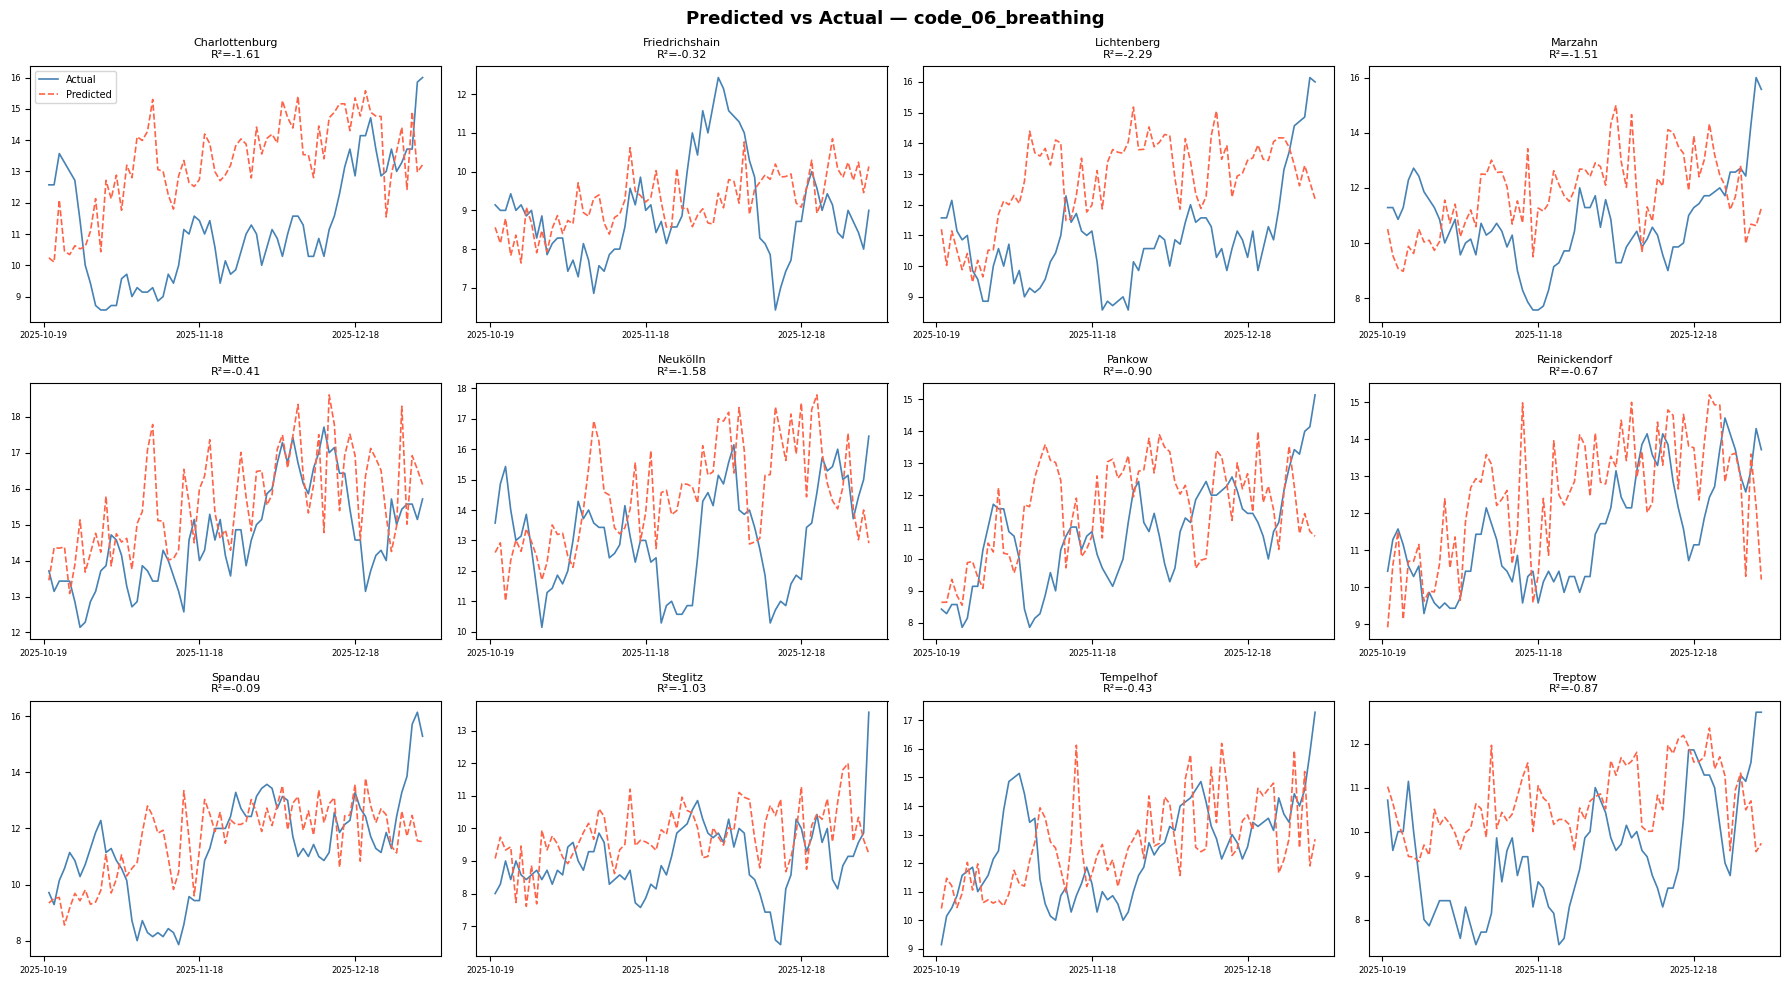

Saved → inference_code_06_breathing.png


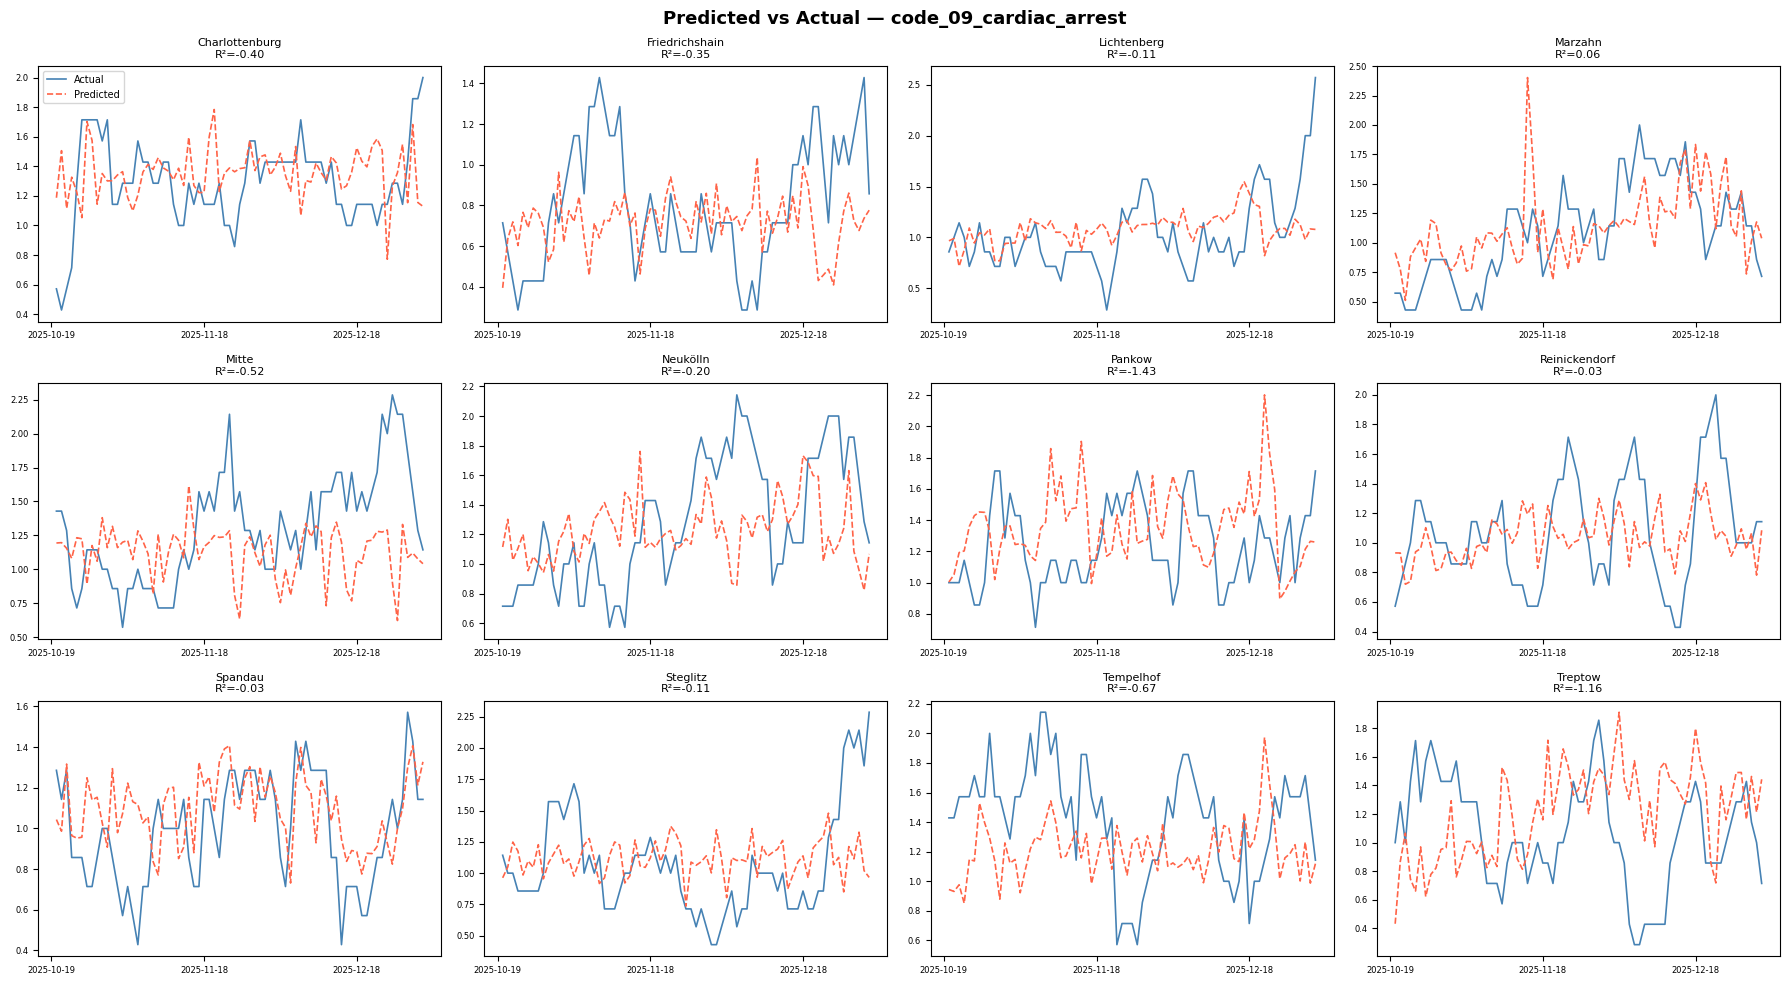

Saved → inference_code_09_cardiac_arrest.png


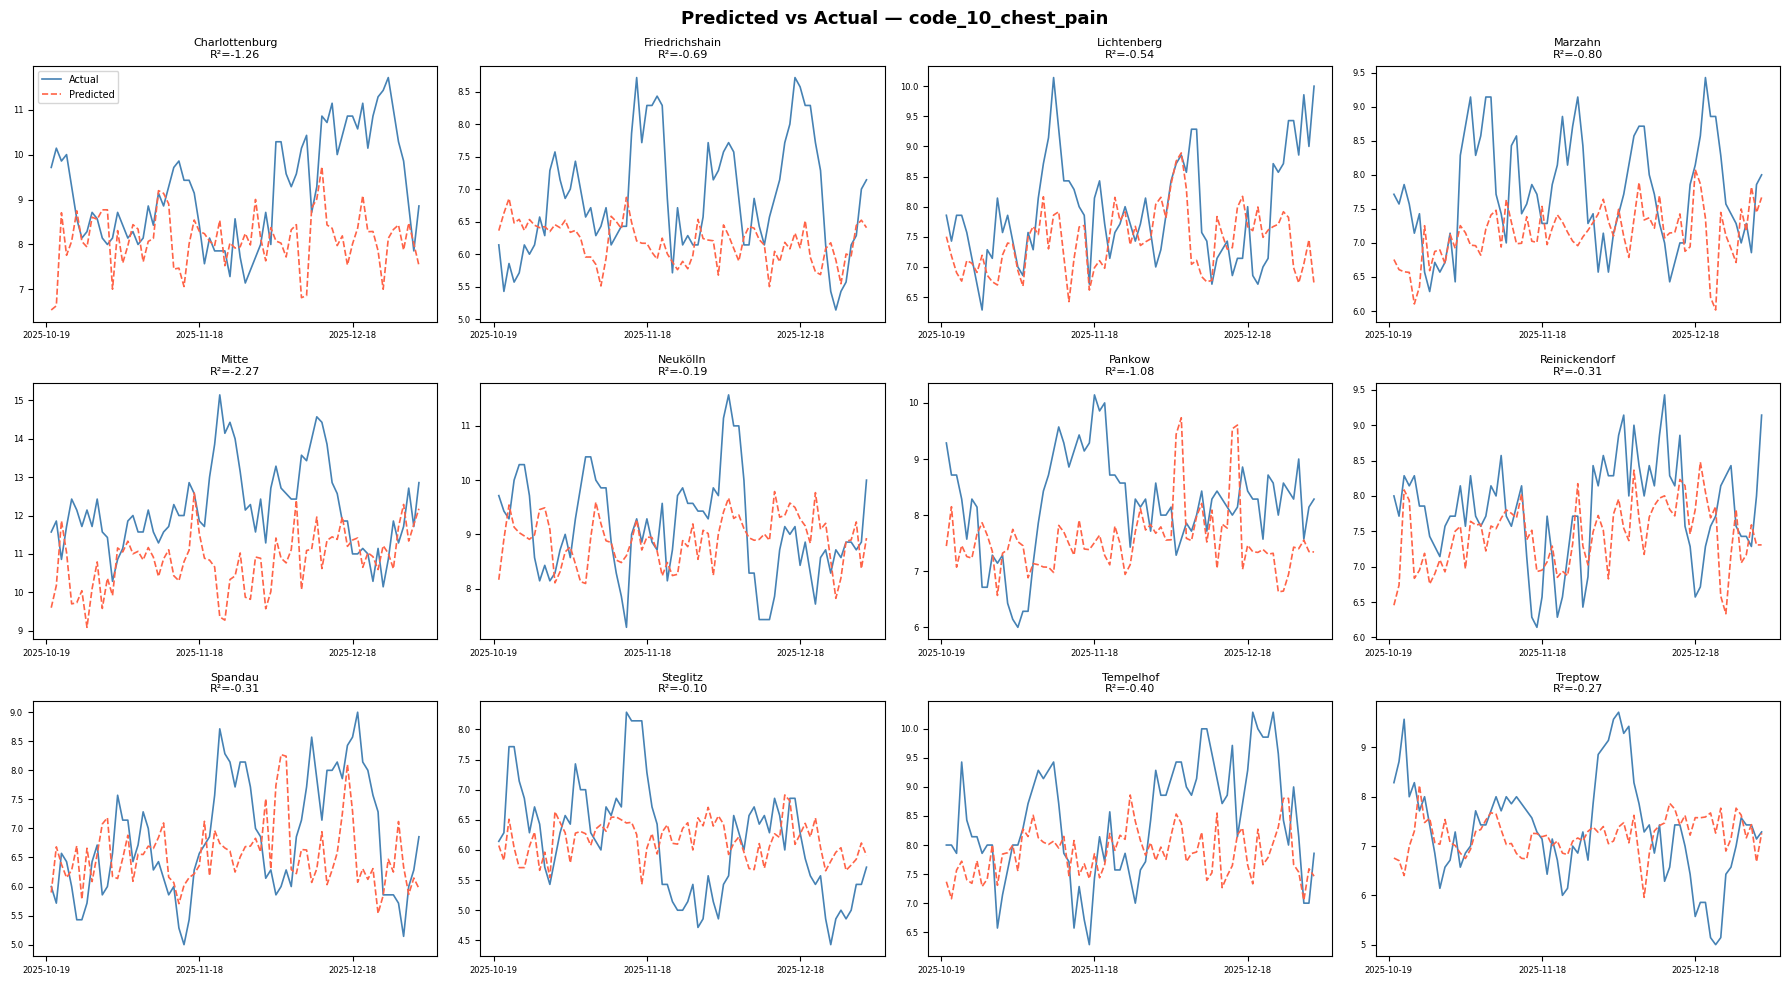

Saved → inference_code_10_chest_pain.png


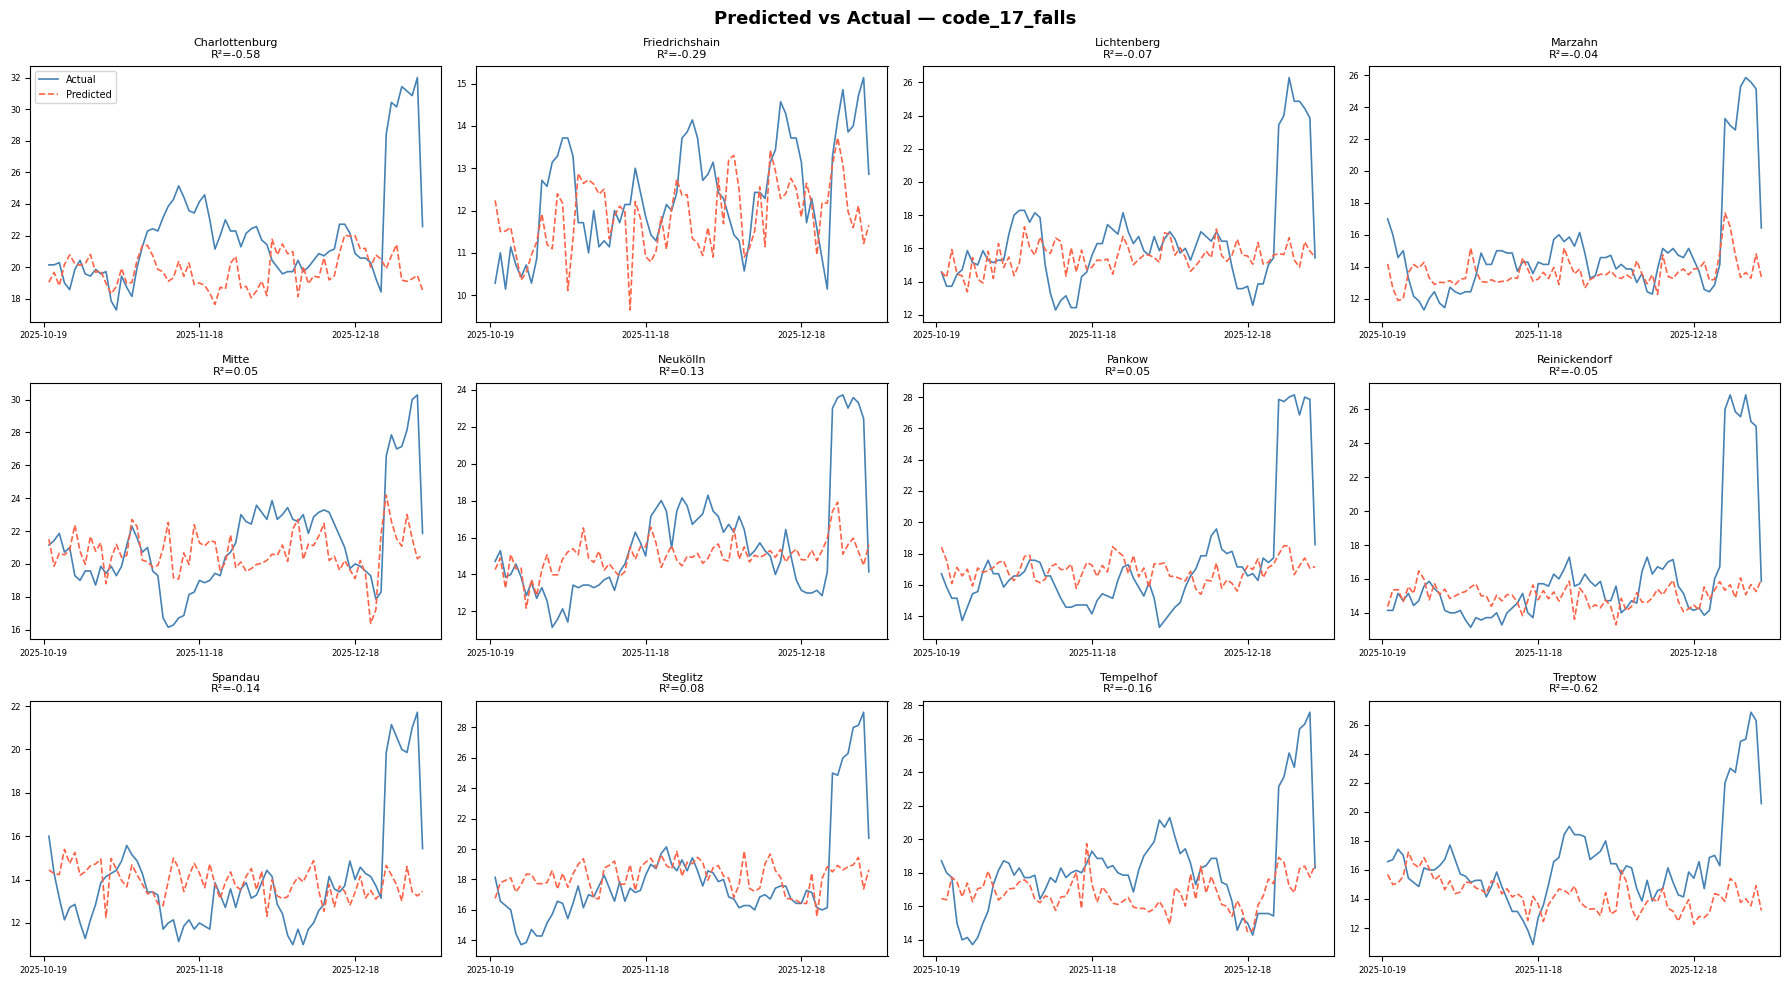

Saved → inference_code_17_falls.png


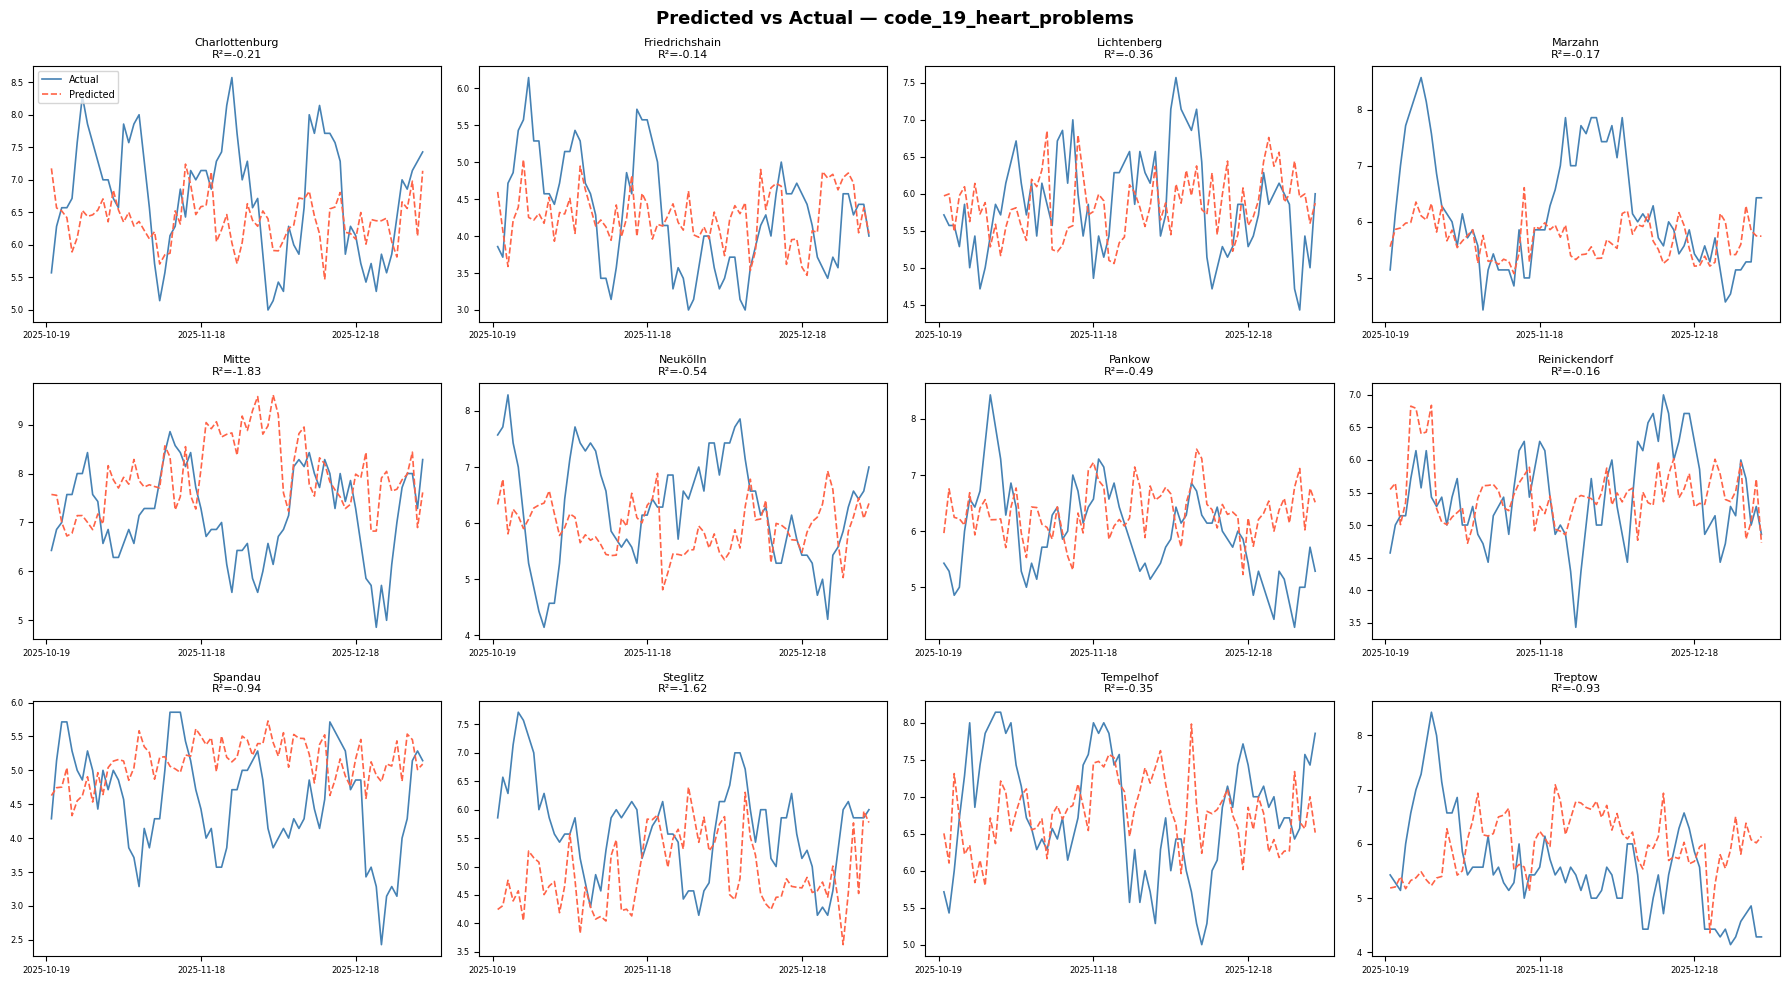

Saved → inference_code_19_heart_problems.png


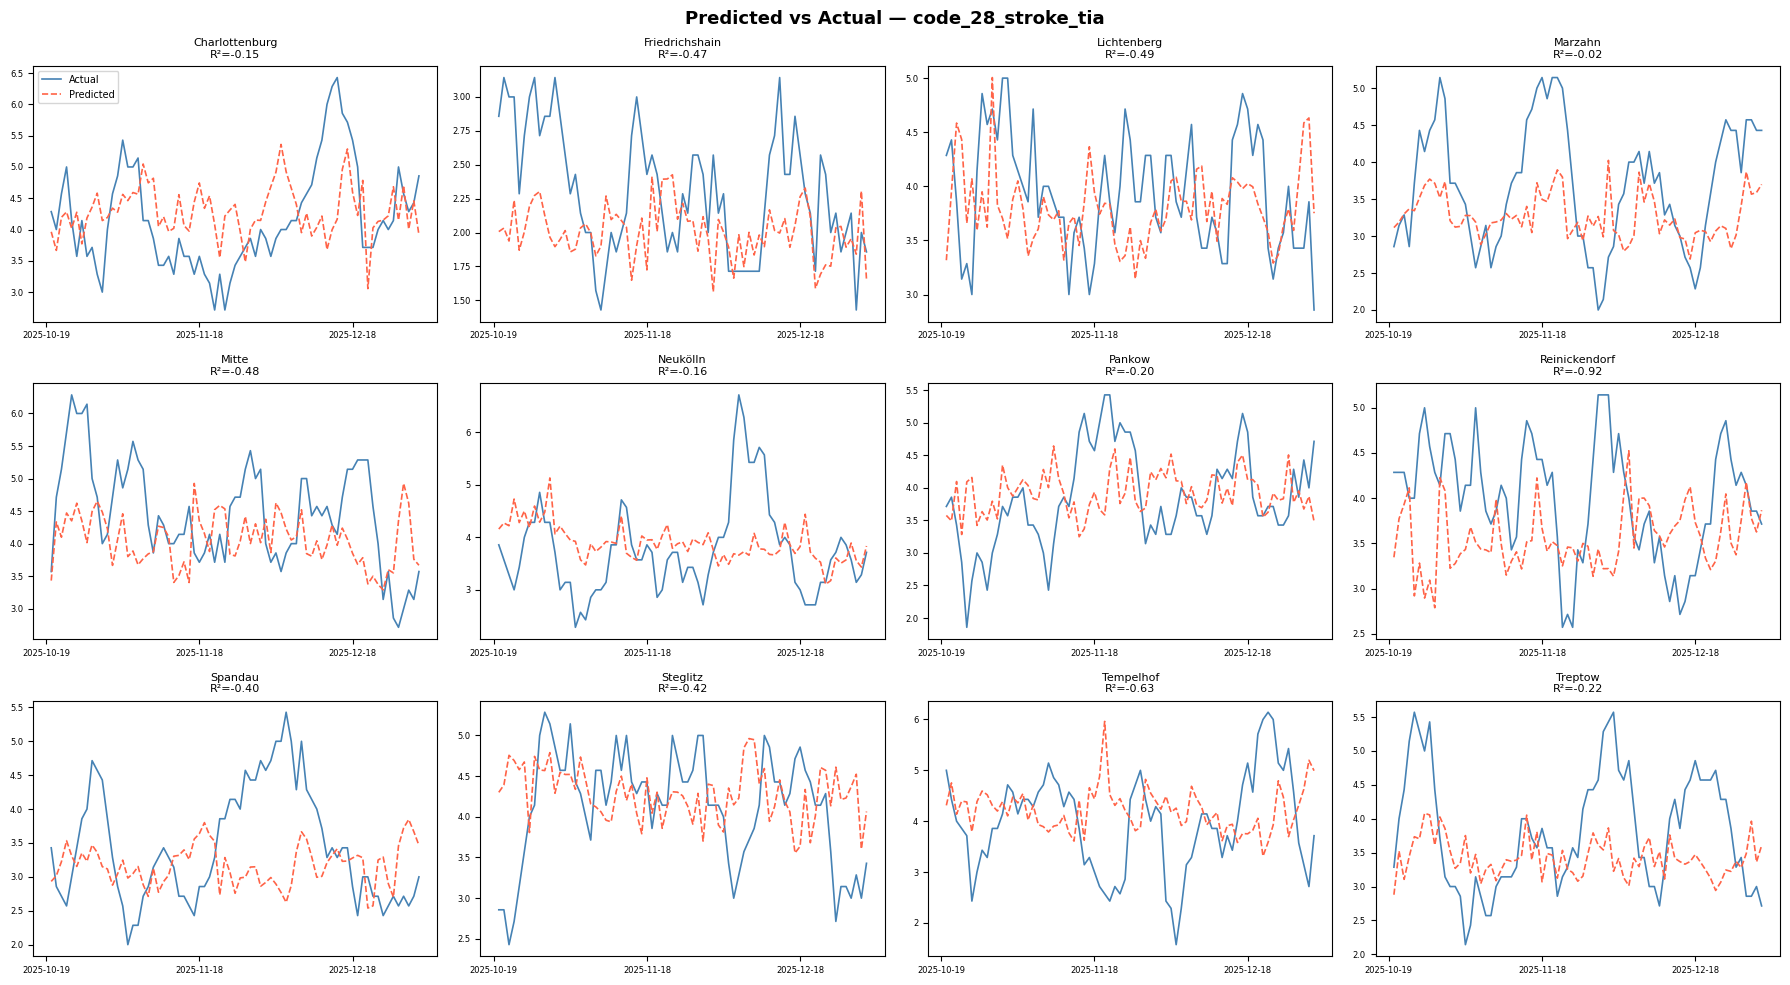

Saved → inference_code_28_stroke_tia.png


In [22]:
for tgt in TARGETS:
    fig, axes = plt.subplots(3, 4, figsize=(18, 10), sharey=False)
    fig.suptitle(f'Predicted vs Actual — {tgt}', fontsize=13, fontweight='bold')

    for ax, district in zip(axes.flat, DISTRICTS):
        if district not in all_preds:
            ax.set_visible(False)
            continue
        pdf   = all_preds[district].sort_values('date')
        act   = f'{tgt}_actual'
        pred  = f'{tgt}_pred'
        if act not in pdf.columns:
            ax.set_visible(False)
            continue
        row   = metrics_df[(metrics_df.district == district) & (metrics_df.target == tgt)]
        r2_val = row['r2'].values[0] if len(row) else np.nan
        ax.plot(pdf['date'], pdf[act],  label='Actual',    lw=1.2, color='steelblue')
        ax.plot(pdf['date'], pdf[pred], label='Predicted', lw=1.2, color='tomato', ls='--')
        ax.set_title(f"{district.split('-')[0]}\nR²={r2_val:.2f}", fontsize=8)
        ax.tick_params(labelsize=6)
        ax.xaxis.set_major_locator(plt.MaxNLocator(3))
    axes[0, 0].legend(fontsize=7, loc='upper left')
    plt.tight_layout()
    plt.savefig(PROC_DIR / f'inference_{tgt}.png', dpi=120, bbox_inches='tight')
    plt.show()
    print(f'Saved → inference_{tgt}.png')

## 6. Feature Importance (Aggregated Across Districts)

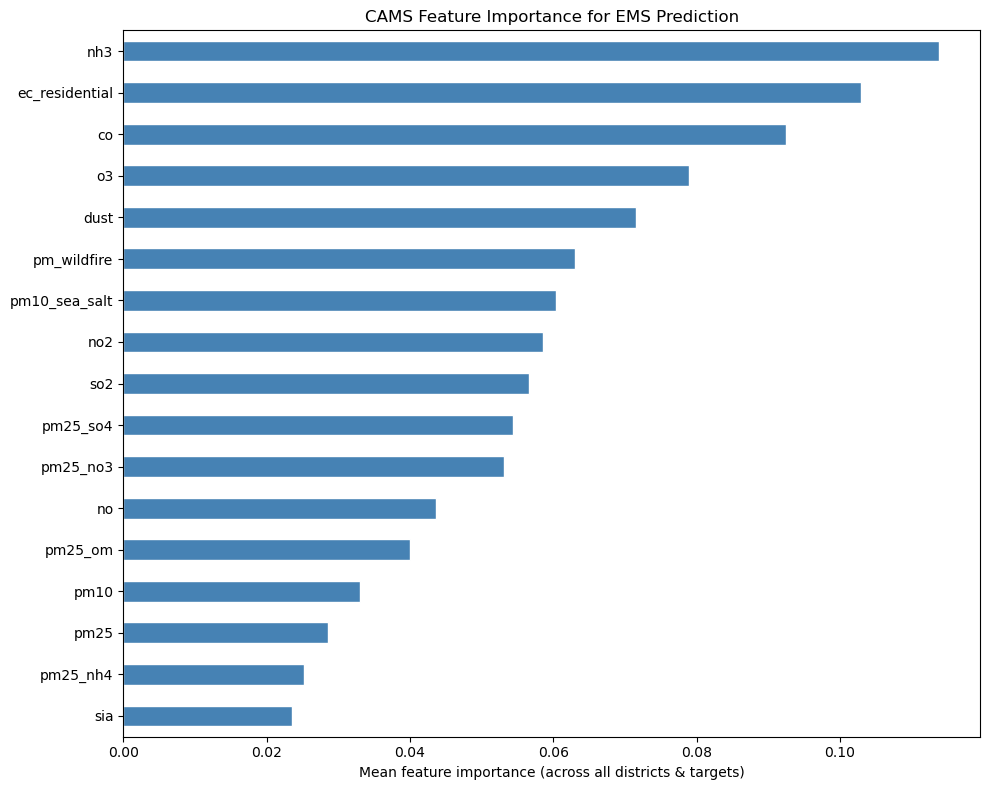

Saved → feature_importance.png


In [23]:
importances = {tgt: np.zeros(len(ALL_FEATURES)) for tgt in TARGETS}

for district, models in all_models.items():
    for tgt, (gbr, scaler) in models.items():
        importances[tgt] += gbr.feature_importances_

# Normalise
for tgt in TARGETS:
    importances[tgt] /= len(all_models)

imp_df = pd.DataFrame(importances, index=ALL_FEATURES)
imp_df['mean'] = imp_df.mean(axis=1)
imp_df = imp_df.sort_values('mean', ascending=True)

fig, ax = plt.subplots(figsize=(10, 8))
imp_df['mean'].plot.barh(ax=ax, color='steelblue', edgecolor='white')
ax.set_xlabel('Mean feature importance (across all districts & targets)')
ax.set_title('CAMS Feature Importance for EMS Prediction')
plt.tight_layout()
plt.savefig(PROC_DIR / 'feature_importance.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved → feature_importance.png')

## 7. District R² Heatmap

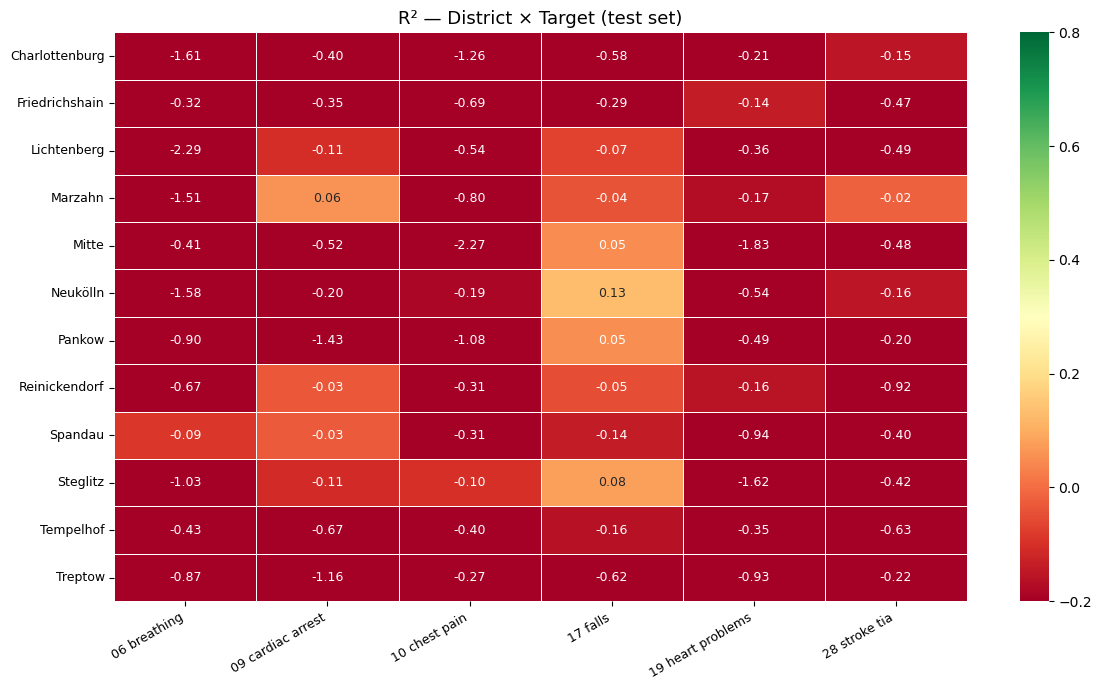

Saved → district_r2_heatmap.png


In [24]:
import seaborn as sns

hmap = metrics_df.pivot_table(index='district', columns='target', values='r2')

# Shorten district names for display
hmap.index = [d.split('-')[0] for d in hmap.index]
hmap.columns = [c.replace('code_', '').replace('_', ' ') for c in hmap.columns]

fig, ax = plt.subplots(figsize=(12, 7))
sns.heatmap(
    hmap, annot=True, fmt='.2f', cmap='RdYlGn',
    vmin=-0.2, vmax=0.8, linewidths=0.5, ax=ax,
    annot_kws={'size': 9}
)
ax.set_title('R² — District × Target (test set)', fontsize=13)
ax.set_xlabel('')
ax.set_ylabel('')
plt.xticks(rotation=30, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.savefig(PROC_DIR / 'district_r2_heatmap.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved → district_r2_heatmap.png')

## 8. Inference Function

Use trained models to predict tomorrow's EMS demand given a CAMS AQ forecast.

In [25]:
def infer(date: str, cams_row: dict) -> pd.DataFrame:
    """
    Predict EMS counts for all districts on a given date.

    Parameters
    ----------
    date     : 'YYYY-MM-DD'
    cams_row : dict of AQ values (same keys as AQ_FEATURES_AVAIL)
               Can be city-wide or district-specific; districts not in dict
               fall back to city-wide values.

    Returns
    -------
    DataFrame with columns: district, target, predicted_count
    """
    ts  = pd.Timestamp(date)
    doy = ts.day_of_year
    temporal = {
        'day_of_week': ts.dayofweek,
        'is_weekend':  int(ts.dayofweek >= 5),
        'month':       ts.month,
        'doy_sin':     np.sin(2 * np.pi * doy / 365.25),
        'doy_cos':     np.cos(2 * np.pi * doy / 365.25),
    }

    rows = []
    for district, models in all_models.items():
        aq = {f: cams_row.get(f, 0) for f in AQ_FEATURES_AVAIL}
        feat_row = {**aq, **temporal}
        X = np.array([[feat_row.get(f, 0) for f in ALL_FEATURES]])

        for tgt, (gbr, scaler) in models.items():
            X_scaled = scaler.transform(X)
            pred     = float(np.clip(gbr.predict(X_scaled)[0], 0, None))
            rows.append({'district': district, 'target': tgt, 'predicted_count': round(pred, 2)})

    return pd.DataFrame(rows).sort_values(['district', 'target']).reset_index(drop=True)


# --- Example: infer for the last available CAMS day ---
last_cams = cams[cams.district == 'Mitte'].sort_values('date').iloc[-1]
example_date = str(last_cams['date'].date())
example_aq   = {f: last_cams[f] for f in AQ_FEATURES_AVAIL if f in last_cams}

print(f'Inference for {example_date}:')
result = infer(example_date, example_aq)
print(result.to_string(index=False))

Inference for 2025-12-31:
                  district                 target  predicted_count
Charlottenburg-Wilmersdorf      code_06_breathing            13.22
Charlottenburg-Wilmersdorf code_09_cardiac_arrest             1.13
Charlottenburg-Wilmersdorf     code_10_chest_pain             7.53
Charlottenburg-Wilmersdorf          code_17_falls            18.54
Charlottenburg-Wilmersdorf code_19_heart_problems             7.14
Charlottenburg-Wilmersdorf     code_28_stroke_tia             3.92
  Friedrichshain-Kreuzberg      code_06_breathing             9.73
  Friedrichshain-Kreuzberg code_09_cardiac_arrest             0.75
  Friedrichshain-Kreuzberg     code_10_chest_pain             6.37
  Friedrichshain-Kreuzberg          code_17_falls            11.66
  Friedrichshain-Kreuzberg code_19_heart_problems             3.87
  Friedrichshain-Kreuzberg     code_28_stroke_tia             1.78
               Lichtenberg      code_06_breathing            11.85
               Lichtenberg code_09_c

## 9. Save Models

## 10. Population Density Overlay & Risk Level Classification

In [32]:
import geopandas as gpd
import json

# ── Population stats (2023, Statistik Berlin Brandenburg) ────────────────────
DISTRICT_STATS = {
    'Mitte':                     {'population': 386181, 'area_km2': 39.47},
    'Friedrichshain-Kreuzberg':  {'population': 294099, 'area_km2': 20.16},
    'Pankow':                    {'population': 415257, 'area_km2': 103.01},
    'Charlottenburg-Wilmersdorf':{'population': 344207, 'area_km2': 64.74},
    'Spandau':                   {'population': 243977, 'area_km2': 91.91},
    'Steglitz-Zehlendorf':       {'population': 308080, 'area_km2': 102.49},
    'Tempelhof-Schöneberg':      {'population': 359199, 'area_km2': 53.09},
    'Neukölln':                  {'population': 328826, 'area_km2': 44.93},
    'Treptow-Köpenick':          {'population': 275469, 'area_km2': 168.42},
    'Marzahn-Hellersdorf':       {'population': 265225, 'area_km2': 61.74},
    'Lichtenberg':               {'population': 298187, 'area_km2': 52.29},
    'Reinickendorf':             {'population': 268568, 'area_km2': 89.49},
}

pop_df = pd.DataFrame.from_dict(DISTRICT_STATS, orient='index').reset_index()
pop_df.columns = ['district', 'population', 'area_km2']
pop_df['pop_density'] = (pop_df['population'] / pop_df['area_km2']).round(1)
MAX_DENSITY = pop_df['pop_density'].max()

# ── Load Berlin district GeoDataFrame ────────────────────────────────────────
gdf = gpd.read_file('/fs2/toby/CmP/data/raw/aux/Berlin_Bezirksgrenzen_-351901266556327970.geojson')
# # Ensure district column is present
# if 'district' not in gdf.columns:
#     for col in ['Gemeinde_name', 'BEZNAME', 'name', 'Bezirksname', 'GEN']:
#         if col in gdf.columns:
#             gdf = gdf.rename(columns={col: 'district'})
#             break

gdf = gdf.merge(pop_df, left_on='Gemeinde_n',right_on='district')
print(f'GeoDataFrame: {len(gdf)} districts, CRS={gdf.crs}')
gdf[['district', 'population', 'pop_density']].sort_values('pop_density', ascending=False)

GeoDataFrame: 12 districts, CRS=EPSG:4326


,district,population,pop_density
10,Friedrichshain-Kreuzberg,294099,14588.2
9,Mitte,386181,9784.2
4,Neukölln,328826,7318.6
11,Tempelhof-Schöneberg,359199,6765.9
5,Lichtenberg,298187,5702.6
1,Charlottenburg-Wilmersdorf,344207,5316.8
6,Marzahn-Hellersdorf,265225,4295.8
3,Pankow,415257,4031.2
8,Steglitz-Zehlendorf,308080,3006.0
0,Reinickendorf,268568,3001.1


In [33]:
gdf

,OBJECTID,Gemeinde_n,Gemeinde_s,Land_name,Land_schlu,Schluessel,geometry,district,population,area_km2,pop_density
0,1,Reinickendorf,012,Berlin,11,11000012,"POLYGON ((13.32074 52.6266, 13.32104 52.62658,...",Reinickendorf,268568,89.49,3001.1
1,2,Charlottenburg-Wilmersdorf,004,Berlin,11,11000004,"POLYGON ((13.32111 52.52446, 13.32137 52.52452...",Charlottenburg-Wilmersdorf,344207,64.74,5316.8
2,3,Treptow-Köpenick,009,Berlin,11,11000009,"POLYGON ((13.57925 52.39083, 13.57894 52.39078...",Treptow-Köpenick,275469,168.42,1635.6
3,4,Pankow,003,Berlin,11,11000003,"MULTIPOLYGON (((13.50481 52.6196, 13.50484 52....",Pankow,415257,103.01,4031.2
4,5,Neukölln,008,Berlin,11,11000008,"POLYGON ((13.45832 52.48569, 13.45856 52.48552...",Neukölln,328826,44.93,7318.6
5,6,Lichtenberg,011,Berlin,11,11000011,"POLYGON ((13.52316 52.47424, 13.52289 52.47444...",Lichtenberg,298187,52.29,5702.6
6,7,Marzahn-Hellersdorf,010,Berlin,11,11000010,"POLYGON ((13.61317 52.47213, 13.61298 52.47197...",Marzahn-Hellersdorf,265225,61.74,4295.8
7,8,Spandau,005,Berlin,11,11000005,"POLYGON ((13.23119 52.56124, 13.23135 52.56112...",Spandau,243977,91.91,2654.5
8,9,Steglitz-Zehlendorf,006,Berlin,11,11000006,"POLYGON ((13.31952 52.46699, 13.31984 52.46698...",Steglitz-Zehlendorf,308080,102.49,3006.0
9,10,Mitte,001,Berlin,11,11000001,"POLYGON ((13.37721 52.56091, 13.37727 52.56114...",Mitte,386181,39.47,9784.2


In [34]:
# ── WHO 24h guidelines (µg/m³) ──────────────────────────────────────────────
WHO = {'pm25': 15, 'pm10': 45, 'no2': 25, 'o3': 100, 'so2': 40}
AQ_W = {'pm25': 0.35, 'pm10': 0.15, 'no2': 0.25, 'o3': 0.20, 'so2': 0.05}

def aq_score(row):
    s = 0.0
    for v, w in AQ_W.items():
        if v in row and not pd.isna(row[v]):
            s += w * min(row[v] / WHO[v], 1.0)
    return round(s, 4)

def risk_classify(score):
    if score >= 0.55: return 'High'
    if score >= 0.30: return 'Medium'
    return 'Low'

# ── Build risk scores from available predictions ──────────────────────────────
# Sum predicted EMS counts across all targets per district per date
def collect_predictions(all_preds, all_dates_sorted):
    rows = []
    for district, pdf in all_preds.items():
        pred_cols = [c for c in pdf.columns if c.endswith('_pred')]
        pdf = pdf.copy()
        pdf['total_predicted_ems'] = pdf[pred_cols].sum(axis=1)
        rows.append(pdf[['date', 'total_predicted_ems']].assign(district=district))
    return pd.concat(rows, ignore_index=True)

ems_pred_df = collect_predictions(all_preds, all_dates)

# Merge with CAMS city-wide AQ for the test period
cams_all = pd.read_csv(PROC_DIR / 'cams_daily_district_2025.csv', parse_dates=['date'])

risk_df = pd.merge(
    pd.merge(cams_all, ems_pred_df, on=['date', 'district'], how='inner'),
    pop_df[['district', 'population', 'pop_density']], on='district', how='left'
)

risk_df['aq_score']       = risk_df.apply(aq_score, axis=1)
risk_df['density_factor'] = (risk_df['pop_density'] / MAX_DENSITY).clip(0, 1).round(4)

max_ems_rate = (risk_df['total_predicted_ems'] / (risk_df['population'] / 1000)).quantile(0.95)
risk_df['ems_factor'] = (
    (risk_df['total_predicted_ems'] / (risk_df['population'] / 1000)) / max_ems_rate
).clip(0, 1).fillna(0).round(4)

risk_df['risk_score'] = (
    0.40 * risk_df['aq_score'] +
    0.35 * risk_df['density_factor'] +
    0.25 * risk_df['ems_factor']
).round(4)
risk_df['risk_level'] = risk_df['risk_score'].apply(risk_classify)

# Save
risk_out = PROC_DIR / 'risk_scores_2025.csv'
risk_df[['date', 'district', 'population', 'pop_density',
         'pm25', 'pm10', 'no2', 'o3', 'so2',
         'aq_score', 'density_factor', 'ems_factor',
         'risk_score', 'risk_level']].to_csv(risk_out, index=False)

print(f'Risk scores saved → {risk_out}')
print(f'\nRisk level distribution:\n{risk_df.risk_level.value_counts().to_string()}')
print(f'\nMean risk score by district:')
print(
    risk_df.groupby('district')['risk_score'].mean()
    .sort_values(ascending=False).round(3).to_string()
)

Risk scores saved → ../data/processed/risk_scores_2025.csv

Risk level distribution:
risk_level
Medium    469
High      407

Mean risk score by district:
district
Friedrichshain-Kreuzberg      0.727
Mitte                         0.670
Neukölln                      0.591
Lichtenberg                   0.565
Charlottenburg-Wilmersdorf    0.560
Tempelhof-Schöneberg          0.559
Marzahn-Hellersdorf           0.527
Reinickendorf                 0.522
Spandau                       0.508
Pankow                        0.471
Steglitz-Zehlendorf           0.468
Treptow-Köpenick              0.460


### Static Choropleth Maps — Population Density, AQ Score, Risk Level

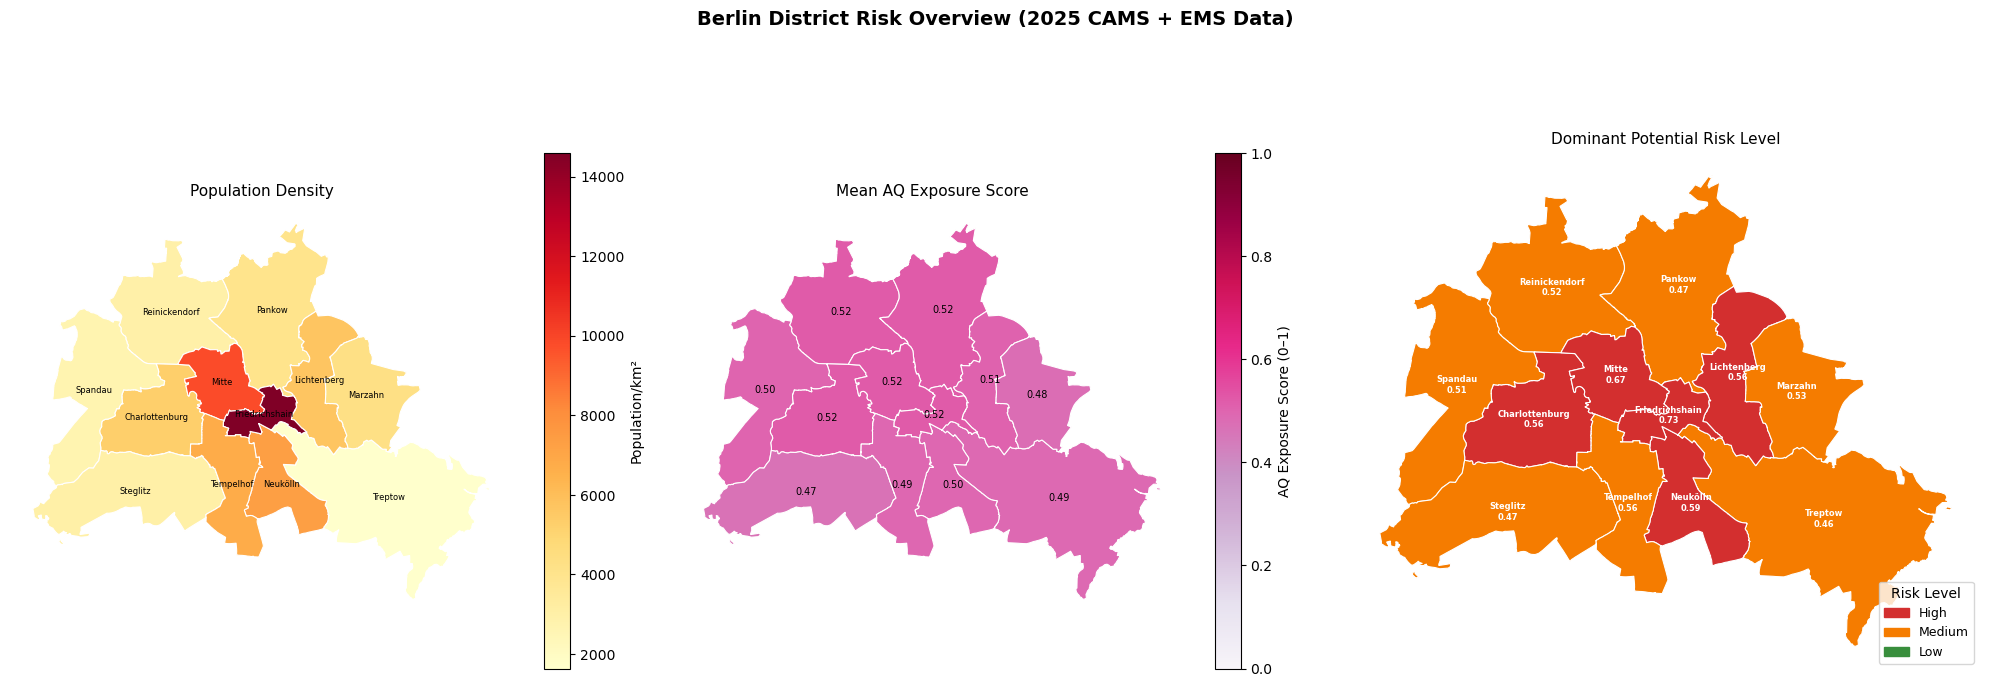

Saved → berlin_risk_map.png


In [35]:
from matplotlib.patches import Patch
from matplotlib.colors import Normalize, LinearSegmentedColormap
import matplotlib.cm as cm

# Merge mean risk metrics onto GeoDataFrame
risk_mean = (
    risk_df.groupby('district')
    .agg(mean_aq=('aq_score','mean'),
         mean_density=('density_factor','mean'),
         mean_ems=('ems_factor','mean'),
         mean_risk=('risk_score','mean'),
         dominant_risk=('risk_level', lambda x: x.value_counts().index[0]))
    .reset_index()
)

gdf_plot = gdf.merge(risk_mean, on='district', how='left').to_crs(epsg=3857)
gdf_plot['centroid'] = gdf_plot.geometry.centroid

fig, axes = plt.subplots(1, 3, figsize=(20, 8))
fig.suptitle('Berlin District Risk Overview (2025 CAMS + EMS Data)', fontsize=14, fontweight='bold')

# ── Panel 1: Population density ───────────────────────────────────────────────
ax = axes[0]
gdf_plot.plot(column='pop_density', cmap='YlOrRd', legend=True,
              legend_kwds={'label': 'Population/km²', 'shrink': 0.7},
              ax=ax, edgecolor='white', linewidth=0.8)
for _, row in gdf_plot.iterrows():
    ax.annotate(row['district'].split('-')[0], xy=(row.centroid.x, row.centroid.y),
                fontsize=6, ha='center', va='center', color='black')
ax.set_title('Population Density', fontsize=11)
ax.axis('off')

# ── Panel 2: Mean AQ exposure score ──────────────────────────────────────────
ax = axes[1]
gdf_plot.plot(column='mean_aq', cmap='PuRd', legend=True,
              legend_kwds={'label': 'AQ Exposure Score (0–1)', 'shrink': 0.7},
              vmin=0, vmax=1,
              ax=ax, edgecolor='white', linewidth=0.8)
for _, row in gdf_plot.iterrows():
    ax.annotate(f"{row['mean_aq']:.2f}", xy=(row.centroid.x, row.centroid.y),
                fontsize=7, ha='center', va='center', color='black')
ax.set_title('Mean AQ Exposure Score', fontsize=11)
ax.axis('off')

# ── Panel 3: Dominant risk level ─────────────────────────────────────────────
ax = axes[2]
RISK_COLORS = {'High': '#d32f2f', 'Medium': '#f57c00', 'Low': '#388e3c'}
gdf_plot['risk_color'] = gdf_plot['dominant_risk'].map(RISK_COLORS).fillna('#aaaaaa')
gdf_plot.plot(color=gdf_plot['risk_color'], ax=ax, edgecolor='white', linewidth=0.8)
for _, row in gdf_plot.iterrows():
    ax.annotate(row['district'].split('-')[0] + f"\n{row['mean_risk']:.2f}",
                xy=(row.centroid.x, row.centroid.y),
                fontsize=6, ha='center', va='center', color='white',
                fontweight='bold')
legend_patches = [Patch(color=c, label=l) for l, c in RISK_COLORS.items()]
ax.legend(handles=legend_patches, loc='lower right', fontsize=9, title='Risk Level')
ax.set_title('Dominant Potential Risk Level', fontsize=11)
ax.axis('off')

plt.tight_layout()
plt.savefig(PROC_DIR / 'berlin_risk_map.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → berlin_risk_map.png')

### Interactive Map (Folium) — Risk Level per District

In [36]:
import folium
from folium.features import GeoJsonTooltip

# Use WGS84 for Folium
gdf_wgs = gdf.merge(risk_mean, on='district', how='left').to_crs(epsg=4326)

FOLIUM_COLORS = {'High': '#d32f2f', 'Medium': '#f57c00', 'Low': '#388e3c'}

m = folium.Map(location=[52.52, 13.405], zoom_start=10, tiles='CartoDB positron')

for _, row in gdf_wgs.iterrows():
    if row.geometry is None:
        continue
    color = FOLIUM_COLORS.get(row.get('dominant_risk', 'Low'), '#aaaaaa')
    risk_score_val = row.get('mean_risk', 0)
    aq_val  = row.get('mean_aq', 0)
    den_val = row.get('mean_density', 0)
    ems_val = row.get('mean_ems', 0)
    pop     = row.get('population', 0)
    density = row.get('pop_density', 0)

    tooltip_html = f"""
    <b>{row['district']}</b><br>
    Population: {pop:,}<br>
    Density: {density:,.0f}/km²<br>
    ─────────────────<br>
    Risk Level: <b style='color:{color}'>{row.get('dominant_risk','?')}</b><br>
    Risk Score: {risk_score_val:.3f}<br>
    ─────────────────<br>
    AQ Score: {aq_val:.3f}<br>
    Density Factor: {den_val:.3f}<br>
    EMS Factor: {ems_val:.3f}
    """

    folium.GeoJson(
        row.geometry.__geo_interface__,
        style_function=lambda f, c=color, rs=risk_score_val: {
            'fillColor':   c,
            'color':       'white',
            'weight':      1.5,
            'fillOpacity': 0.55 + 0.35 * rs,
        },
        tooltip=folium.Tooltip(tooltip_html),
    ).add_to(m)

# Legend
legend_html = """
<div style='position:fixed;bottom:30px;left:30px;z-index:1000;
            background:white;padding:12px 16px;border-radius:8px;
            box-shadow:2px 2px 6px rgba(0,0,0,0.3);font-family:sans-serif;font-size:13px;'>
  <b>Potential Risk Level</b><br>
  <span style='color:#d32f2f'>&#9632;</span> High &nbsp; (score ≥ 0.55)<br>
  <span style='color:#f57c00'>&#9632;</span> Medium (0.30 – 0.55)<br>
  <span style='color:#388e3c'>&#9632;</span> Low &nbsp; (score &lt; 0.30)<br>
  <hr style='margin:6px 0'>
  <small>Score = 0.4×AQ + 0.35×Density + 0.25×EMS rate</small>
</div>
"""
m.get_root().html.add_child(folium.Element(legend_html))

map_path = PROC_DIR / 'berlin_risk_interactive.html'
m.save(str(map_path))
print(f'Interactive map saved → {map_path}')
m

Interactive map saved → ../data/processed/berlin_risk_interactive.html


### Risk Timeline — How Risk Level Evolves Per District

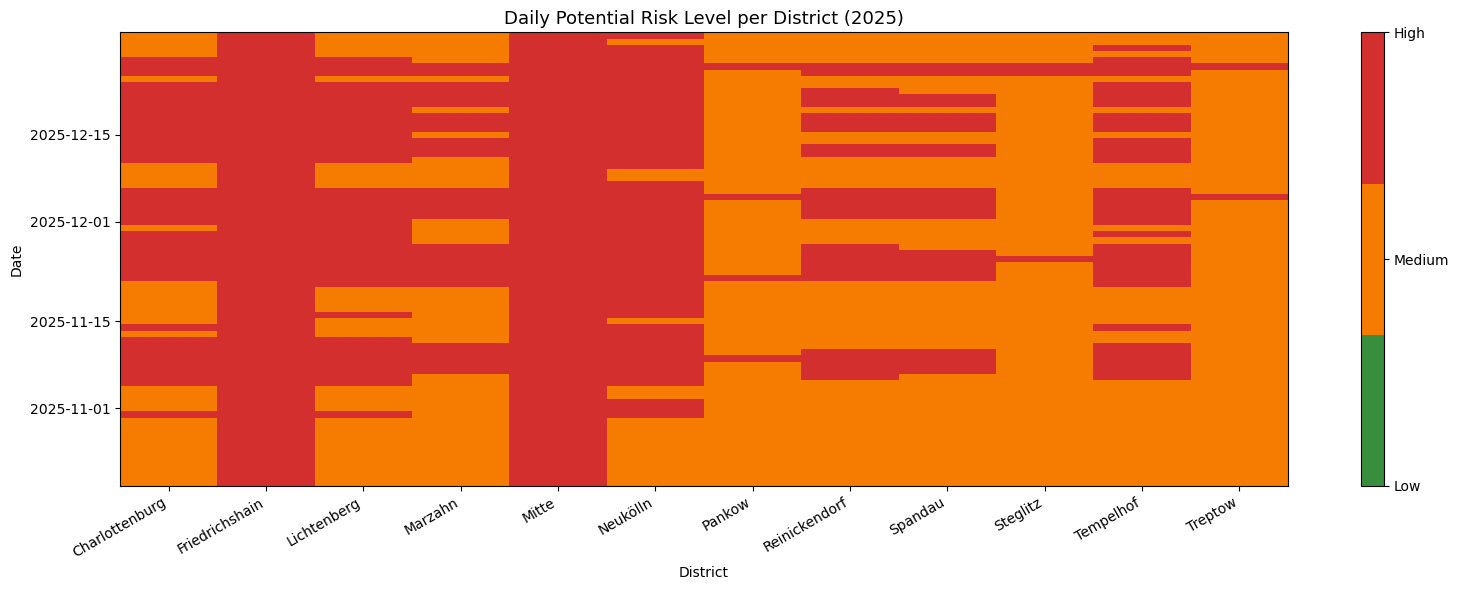

Saved → risk_timeline.png


In [37]:
RISK_NUM = {'Low': 0, 'Medium': 1, 'High': 2}
risk_df['risk_num'] = risk_df['risk_level'].map(RISK_NUM)

pivot = risk_df.pivot_table(index='date', columns='district', values='risk_num')

fig, ax = plt.subplots(figsize=(16, 6))
cmap_risk = plt.matplotlib.colors.ListedColormap(['#388e3c', '#f57c00', '#d32f2f'])
im = ax.pcolormesh(
    pivot.columns,
    pivot.index,
    pivot.values,
    cmap=cmap_risk, vmin=0, vmax=2
)
ax.set_title('Daily Potential Risk Level per District (2025)', fontsize=13)
ax.set_xlabel('District')
ax.set_ylabel('Date')
ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels([d.split('-')[0] for d in pivot.columns], rotation=30, ha='right')
cbar = plt.colorbar(im, ax=ax, ticks=[0, 1, 2])
cbar.set_ticklabels(['Low', 'Medium', 'High'])
plt.tight_layout()
plt.savefig(PROC_DIR / 'risk_timeline.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved → risk_timeline.png')

### Live Inference with Risk Level — Given Tomorrow's CAMS Forecast

In [38]:
def infer_with_risk(date: str, cams_row: dict) -> pd.DataFrame:
    """
    Full inference pipeline: AQ forecast → predicted EMS counts → Potential Risk level.

    Parameters
    ----------
    date     : 'YYYY-MM-DD'
    cams_row : dict mapping AQ variable names (pm25, pm10, no2, o3, so2, …) to µg/m³ values

    Returns
    -------
    DataFrame: district | predicted EMS targets | aq_score | density_factor |
               ems_factor | risk_score | risk_level
    """
    pred_df = infer(date, cams_row)   # from cell 19 — GBR predictions per target

    # Aggregate predicted EMS per district
    pred_wide = pred_df.pivot(index='district', columns='target', values='predicted_count').reset_index()
    pred_wide['total_predicted_ems'] = pred_wide[[c for c in pred_wide.columns if c != 'district']].sum(axis=1)

    # Attach population
    result = pred_wide.merge(pop_df[['district', 'population', 'pop_density']], on='district', how='left')

    # AQ scores — same for all districts (city-wide forecast given)
    aq = aq_score(cams_row)
    result['aq_score'] = aq
    result['density_factor'] = (result['pop_density'] / MAX_DENSITY).clip(0, 1).round(4)
    result['ems_rate']  = result['total_predicted_ems'] / (result['population'] / 1000)
    result['ems_factor'] = (result['ems_rate'] / max_ems_rate).clip(0, 1).round(4)

    result['risk_score'] = (
        0.40 * result['aq_score'] +
        0.35 * result['density_factor'] +
        0.25 * result['ems_factor']
    ).round(4)
    result['risk_level'] = result['risk_score'].apply(risk_classify)

    # Sort by risk level then score
    level_order = {'High': 0, 'Medium': 1, 'Low': 2}
    result['_ord'] = result['risk_level'].map(level_order)
    result = result.sort_values(['_ord', 'risk_score'], ascending=[True, False]).drop(columns='_ord')

    return result[['district', 'population', 'pop_density',
                   'total_predicted_ems', 'aq_score', 'density_factor',
                   'ems_factor', 'risk_score', 'risk_level']].reset_index(drop=True)


# ── Example: use the latest available CAMS day ───────────────────────────────
last_cams_city = cams_all[cams_all.district == 'Mitte'].sort_values('date').iloc[-1]
demo_date = str(last_cams_city['date'].date())
demo_aq   = {f: last_cams_city[f] for f in AQ_FEATURES_AVAIL if f in last_cams_city.index}

print(f'Inference for {demo_date}:')
print(f'AQ inputs: PM2.5={demo_aq.get("pm25",0):.1f}, PM10={demo_aq.get("pm10",0):.1f}, '
      f'NO2={demo_aq.get("no2",0):.1f}, O3={demo_aq.get("o3",0):.1f} µg/m³\n')

risk_result = infer_with_risk(demo_date, demo_aq)

# Colour-coded display
def color_risk(val):
    c = {'High': 'background-color:#ffcdd2', 'Medium': 'background-color:#ffe0b2', 'Low': 'background-color:#c8e6c9'}
    return c.get(val, '')

risk_result.style.applymap(color_risk, subset=['risk_level'])

Inference for 2025-12-31:
AQ inputs: PM2.5=7.2, PM10=10.1, NO2=10.8, O3=55.1 µg/m³



,district,population,pop_density,total_predicted_ems,aq_score,density_factor,ems_factor,risk_score,risk_level
0,Friedrichshain-Kreuzberg,294099,14588.200000,34.160000,0.420600,1.000000,0.672400,0.686300,High
1,Mitte,386181,9784.200000,61.180000,0.420600,0.670700,0.917200,0.632300,High
2,Neukölln,328826,7318.600000,49.620000,0.420600,0.501700,0.873600,0.562200,High
3,Tempelhof-Schöneberg,359199,6765.900000,51.330000,0.420600,0.463800,0.827300,0.537400,Medium
4,Lichtenberg,298187,5702.600000,45.110000,0.420600,0.390900,0.875800,0.524000,Medium
5,Charlottenburg-Wilmersdorf,344207,5316.800000,51.480000,0.420600,0.364500,0.865900,0.512300,Medium
6,Marzahn-Hellersdorf,265225,4295.800000,42.680000,0.420600,0.294500,0.931600,0.504200,Medium
7,Spandau,243977,2654.500000,41.400000,0.420600,0.182000,0.982400,0.477500,Medium
8,Reinickendorf,268568,3001.100000,43.140000,0.420600,0.205700,0.929900,0.472700,Medium
9,Steglitz-Zehlendorf,308080,3006.000000,44.340000,0.420600,0.206100,0.833200,0.448700,Medium


In [39]:
# Persist all models so inference can be run without retraining
for district, models in all_models.items():
    safe_name = district.replace(' ', '_').replace('ö', 'oe').replace('ü', 'ue')
    out_path  = MODEL_DIR / f'district_{safe_name}.joblib'
    joblib.dump({'models': models, 'features': ALL_FEATURES}, str(out_path))

print(f'Saved {len(all_models)} district model bundles to {MODEL_DIR}')

# Quick load test
test_path = MODEL_DIR / f'district_Mitte.joblib'
if test_path.exists():
    loaded = joblib.load(str(test_path))
    print(f'Load test OK — features: {len(loaded["features"])}, targets: {list(loaded["models"].keys())}')

Saved 12 district model bundles to ../models
Load test OK — features: 17, targets: ['code_06_breathing', 'code_09_cardiac_arrest', 'code_10_chest_pain', 'code_17_falls', 'code_19_heart_problems', 'code_28_stroke_tia']
